In [ ]:
import os
import numpy as np
import pandas as pd

from scipy.spatial.distance import cosine

In [ ]:
OUT_DIR = "data/16_round4_light_rebuilt"
os.makedirs(OUT_DIR, exist_ok=True)
print("Output folder:", OUT_DIR)

Output folder: data/16_round4_light_rebuilt


In [ ]:
round1_df = pd.read_csv("round1_improved_baseline_dataset.csv")
aligned_df = pd.read_csv("dataset_v2_aligned_finbert_updated.csv")
raw_emb = np.load("finbert_embeddings_raw_updated.npy")

print("Round 1 shape:", round1_df.shape)
print("Aligned shape:", aligned_df.shape)
print("Raw embedding shape:", raw_emb.shape)

assert len(aligned_df) == raw_emb.shape[0], "aligned_df and raw_emb length mismatch"

Round 1 shape: (2181, 41)
Aligned shape: (2247, 26)
Raw embedding shape: (2247, 768)


In [ ]:
for df_ in [round1_df, aligned_df]:
    df_["ticker"] = df_["ticker"].astype(str).str.strip().str.upper()
    df_["filing_type"] = df_["filing_type"].astype(str).str.strip().str.upper()
    df_["filing_date"] = pd.to_datetime(df_["filing_date"], errors="coerce")

if "accession_number" in round1_df.columns:
    round1_df["accession_number"] = round1_df["accession_number"].astype(str).str.strip()

if "accession_number" in aligned_df.columns:
    aligned_df["accession_number"] = aligned_df["accession_number"].astype(str).str.strip()

In [ ]:
aligned_df = aligned_df.copy()
aligned_df["emb_idx"] = np.arange(len(aligned_df))

print(aligned_df[["ticker", "filing_date", "filing_type", "emb_idx"]].head())

  ticker filing_date filing_type  emb_idx
0   AAPL  2019-01-30        10-Q        0
1   AAPL  2019-05-01        10-Q        1
2   AAPL  2019-07-31        10-Q        2
3   AAPL  2020-01-29        10-Q        3
4   AAPL  2020-05-01        10-Q        4


In [ ]:
merge_keys = ["ticker", "filing_date", "filing_type"]
if "accession_number" in round1_df.columns and "accession_number" in aligned_df.columns:
    merge_keys.append("accession_number")

df = round1_df.merge(
    aligned_df[merge_keys + ["emb_idx"]],
    on=merge_keys,
    how="left"
)

print("Merged shape:", df.shape)
print("Missing emb_idx rows:", df["emb_idx"].isna().sum())

Merged shape: (2181, 42)
Missing emb_idx rows: 0


In [ ]:
df = df.dropna(subset=["emb_idx"]).copy()
df["emb_idx"] = df["emb_idx"].astype(int)

df = df.sort_values(["ticker", "filing_date"]).reset_index(drop=True)

print("Working shape:", df.shape)
df.head()

Working shape: (2181, 42)


,ticker,cik,filing_date,filing_type,accession_number,year,quarter,cik_nolead,acc_nodash,mda_path,...,mean_abs_return_5d,mean_abs_return_10d,max_abs_return_10d,return_skew_10d,return_kurtosis_10d,log_price_tminus1,vol_ratio_5_20,vol_ratio_10_60,log_future_realized_vol_10d,emb_idx
0,AAPL,320193,2019-05-01,10-Q,0000320193-19-000066,2019,2,320193,32019319000066,AAPL_20190501_10-Q_000032019319000066.txt,...,0.007233,0.007704,0.019473,-0.006040,0.587393,3.915367,0.870016,0.974208,-3.810629,1
1,AAPL,320193,2019-07-31,10-Q,0000320193-19-000076,2019,3,320193,32019319000076,AAPL_20190731_10-Q_000032019319000076.txt,...,0.005166,0.008841,0.022854,0.360768,-0.039101,3.954987,0.662464,0.709436,-3.566474,2
2,AAPL,320193,2019-10-31,10-K,0000320193-19-000119,2019,4,320193,32019319000119,AAPL_2019-10-31_10-K_0000320193-19-000119_FAMI...,...,0.009446,0.008896,0.023128,-1.456441,3.091214,4.107836,1.159828,0.733736,-4.628291,2245
3,AAPL,320193,2020-01-29,10-Q,0000320193-20-000010,2020,1,320193,32019320000010,AAPL_20200129_10-Q_000032019320000010.txt,...,0.013792,0.011713,0.029405,-0.158909,0.862831,4.374782,1.468833,1.343708,-3.852132,3
4,AAPL,320193,2020-05-01,10-Q,0000320193-20-000052,2020,2,320193,32019320000052,AAPL_20200501_10-Q_000032019320000052.txt,...,0.019945,0.019764,0.032845,0.076090,-1.717656,4.296605,0.738856,0.523305,-4.397591,4


In [ ]:
df["prev_emb_idx"] = df.groupby("ticker")["emb_idx"].shift(1)

print("Rows without previous filing:", df["prev_emb_idx"].isna().sum())

Rows without previous filing: 123


In [ ]:
def cosine_similarity_safe(a, b):
    if a is None or b is None:
        return np.nan
    if np.isnan(a).any() or np.isnan(b).any():
        return np.nan
    if np.linalg.norm(a) == 0 or np.linalg.norm(b) == 0:
        return np.nan
    return 1 - cosine(a, b)

def cosine_distance_safe(a, b):
    sim = cosine_similarity_safe(a, b)
    if pd.isna(sim):
        return np.nan
    return 1 - sim

def l2_distance_safe(a, b):
    if a is None or b is None:
        return np.nan
    if np.isnan(a).any() or np.isnan(b).any():
        return np.nan
    return np.linalg.norm(a - b)

In [ ]:
cosdist_prev = []
l2_prev = []

for _, row in df.iterrows():
    if pd.isna(row["prev_emb_idx"]):
        cosdist_prev.append(np.nan)
        l2_prev.append(np.nan)
        continue

    curr_vec = raw_emb[int(row["emb_idx"])]
    prev_vec = raw_emb[int(row["prev_emb_idx"])]

    cosdist_prev.append(cosine_distance_safe(curr_vec, prev_vec))
    l2_prev.append(l2_distance_safe(curr_vec, prev_vec))

df["finbert_cosdist_prev"] = cosdist_prev
df["finbert_l2_prev"] = l2_prev

df[["finbert_cosdist_prev", "finbert_l2_prev"]].describe()

,finbert_cosdist_prev,finbert_l2_prev
count,2058.000000,2058.000000
mean,0.014882,1.294443
std,0.026296,1.084039
min,0.000000,0.000000
25%,0.001817,0.576144
50%,0.005039,0.956764
75%,0.013978,1.567260
max,0.185156,6.100934


In [ ]:
centroid_l2 = []

for _, row in df.iterrows():
    ticker = row["ticker"]
    filing_date = row["filing_date"]

    hist_idx = df.loc[
        (df["ticker"] == ticker) & (df["filing_date"] < filing_date),
        "emb_idx"
    ].tolist()

    if len(hist_idx) == 0:
        centroid_l2.append(np.nan)
        continue

    hist_vecs = raw_emb[np.array(hist_idx, dtype=int)]
    centroid = hist_vecs.mean(axis=0)
    curr_vec = raw_emb[int(row["emb_idx"])]

    centroid_l2.append(l2_distance_safe(curr_vec, centroid))

df["finbert_l2_centroid_hist"] = centroid_l2

df["finbert_l2_centroid_hist"].describe()

,finbert_l2_centroid_hist
count,2058.000000
mean,1.285772
std,0.781637
min,0.014831
25%,0.826137
50%,1.067879
75%,1.436306
max,6.100934


In [ ]:
light_safe_features = [
    "finbert_l2_centroid_hist",
    "finbert_cosdist_prev",
    "finbert_l2_prev"
]

light_round4_df = df.dropna(subset=light_safe_features).copy()

print("Original working rows:", len(df))
print("Safe Light Round 4 rows:", len(light_round4_df))
print("Rows lost:", len(df) - len(light_round4_df))

Original working rows: 2181
Safe Light Round 4 rows: 2058
Rows lost: 123


In [ ]:
keep_cols = list(round1_df.columns) + [
    "emb_idx",
    "prev_emb_idx",
    "finbert_l2_centroid_hist",
    "finbert_cosdist_prev",
    "finbert_l2_prev"
]

keep_cols = [c for c in keep_cols if c in light_round4_df.columns]

light_round4_df = light_round4_df[keep_cols].copy()

print("Final safe light Round 4 shape:", light_round4_df.shape)
light_round4_df.head()

Final safe light Round 4 shape: (2058, 46)


,ticker,cik,filing_date,filing_type,accession_number,year,quarter,cik_nolead,acc_nodash,mda_path,...,return_kurtosis_10d,log_price_tminus1,vol_ratio_5_20,vol_ratio_10_60,log_future_realized_vol_10d,emb_idx,prev_emb_idx,finbert_l2_centroid_hist,finbert_cosdist_prev,finbert_l2_prev
1,AAPL,320193,2019-07-31,10-Q,0000320193-19-000076,2019,3,320193,32019319000076,AAPL_20190731_10-Q_000032019319000076.txt,...,-0.039101,3.954987,0.662464,0.709436,-3.566474,2,1.0,0.014831,0.000001,0.014831
2,AAPL,320193,2019-10-31,10-K,0000320193-19-000119,2019,4,320193,32019319000119,AAPL_2019-10-31_10-K_0000320193-19-000119_FAMI...,...,3.091214,4.107836,1.159828,0.733736,-4.628291,2245,2.0,4.649648,0.116782,4.649836
3,AAPL,320193,2020-01-29,10-Q,0000320193-20-000010,2020,1,320193,32019320000010,AAPL_20200129_10-Q_000032019320000010.txt,...,0.862831,4.374782,1.468833,1.343708,-3.852132,3,2245.0,3.028815,0.005710,1.021676
4,AAPL,320193,2020-05-01,10-Q,0000320193-20-000052,2020,2,320193,32019320000052,AAPL_20200501_10-Q_000032019320000052.txt,...,-1.717656,4.296605,0.738856,0.523305,-4.397591,4,3.0,2.296537,0.022513,2.046331
5,AAPL,320193,2020-07-31,10-Q,0000320193-20-000062,2020,3,320193,32019320000062,AAPL_20200731_10-Q_000032019320000062.txt,...,1.031954,4.566325,0.955249,1.276181,-3.828080,5,4.0,1.851830,0.006364,1.063818


In [ ]:
save_path = f"{OUT_DIR}/round4_light_text_surprise_dataset.csv"
light_round4_df.to_csv(save_path, index=False)

print("Saved:", save_path)

Saved: data/16_round4_light_rebuilt/round4_light_text_surprise_dataset.csv


In [ ]:
retention_summary = pd.DataFrame({
    "metric": [
        "rows_round1",
        "rows_light_round4",
        "rows_lost",
        "retention_rate",
        "unique_tickers_round1",
        "unique_tickers_light_round4",
        "target_mean_round1",
        "target_mean_light_round4",
        "target_median_round1",
        "target_median_light_round4"
    ],
    "value": [
        len(round1_df),
        len(light_round4_df),
        len(round1_df) - len(light_round4_df),
        len(light_round4_df) / len(round1_df),
        round1_df["ticker"].nunique(),
        light_round4_df["ticker"].nunique(),
        round1_df["future_realized_vol_10d"].mean(),
        light_round4_df["future_realized_vol_10d"].mean(),
        round1_df["future_realized_vol_10d"].median(),
        light_round4_df["future_realized_vol_10d"].median()
    ]
})

retention_summary

,metric,value
0,rows_round1,2181.000000
1,rows_light_round4,2058.000000
2,rows_lost,123.000000
3,retention_rate,0.943604
4,unique_tickers_round1,123.000000
5,unique_tickers_light_round4,122.000000
6,target_mean_round1,0.018194
7,target_mean_light_round4,0.018219
8,target_median_round1,0.015091
9,target_median_light_round4,0.015183


In [ ]:
retention_summary.to_csv(f"{OUT_DIR}/retention_summary.csv", index=False)
print("Saved retention summary.")

Saved retention summary.


In [ ]:
from google.colab import files

files.download(f"{OUT_DIR}/round4_light_text_surprise_dataset.csv")
files.download(f"{OUT_DIR}/retention_summary.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
OUT_DIR = "data/17_light_round4_full_audit"
os.makedirs(OUT_DIR, exist_ok=True)
print("Output folder:", OUT_DIR)

Output folder: data/17_light_round4_full_audit


In [ ]:
round1 = pd.read_csv("round1_improved_baseline_dataset.csv")
light_round4 = pd.read_csv("round4_light_text_surprise_dataset.csv")

print("Round 1 shape:", round1.shape)
print("Light Round 4 shape:", light_round4.shape)

Round 1 shape: (2181, 41)
Light Round 4 shape: (2058, 46)


In [ ]:
for df_ in [round1, light_round4]:
    df_["ticker"] = df_["ticker"].astype(str).str.strip().str.upper()
    df_["filing_type"] = df_["filing_type"].astype(str).str.strip().str.upper()
    df_["filing_date"] = pd.to_datetime(df_["filing_date"], errors="coerce")

if "accession_number" in round1.columns:
    round1["accession_number"] = round1["accession_number"].astype(str).str.strip()

if "accession_number" in light_round4.columns:
    light_round4["accession_number"] = light_round4["accession_number"].astype(str).str.strip()

In [ ]:
if "accession_number" in round1.columns and "accession_number" in light_round4.columns:
    round1["row_key"] = (
        round1["ticker"].astype(str) + "||" +
        round1["filing_date"].astype(str) + "||" +
        round1["filing_type"].astype(str) + "||" +
        round1["accession_number"].astype(str)
    )

    light_round4["row_key"] = (
        light_round4["ticker"].astype(str) + "||" +
        light_round4["filing_date"].astype(str) + "||" +
        light_round4["filing_type"].astype(str) + "||" +
        light_round4["accession_number"].astype(str)
    )
else:
    round1["row_key"] = (
        round1["ticker"].astype(str) + "||" +
        round1["filing_date"].astype(str) + "||" +
        round1["filing_type"].astype(str)
    )

    light_round4["row_key"] = (
        light_round4["ticker"].astype(str) + "||" +
        light_round4["filing_date"].astype(str) + "||" +
        light_round4["filing_type"].astype(str)
    )

print("Unique Round 1 row keys:", round1["row_key"].nunique())
print("Unique Light Round 4 row keys:", light_round4["row_key"].nunique())

Unique Round 1 row keys: 2181
Unique Light Round 4 row keys: 2058


In [ ]:
round1_keys = set(round1["row_key"])
light_keys = set(light_round4["row_key"])

lost_keys = round1_keys - light_keys
kept_keys = round1_keys & light_keys

lost_df = round1.loc[round1["row_key"].isin(lost_keys)].copy()
kept_df = round1.loc[round1["row_key"].isin(kept_keys)].copy()

print("Round 1 rows:", len(round1))
print("Light Round 4 rows:", len(light_round4))
print("Lost rows:", len(lost_df))
print("Kept rows:", len(kept_df))
print("Retention rate:", len(light_round4) / len(round1))

Round 1 rows: 2181
Light Round 4 rows: 2058
Lost rows: 123
Kept rows: 2058
Retention rate: 0.9436038514442916


In [ ]:
filing_type_audit = pd.DataFrame({
    "round1_count": round1["filing_type"].value_counts(dropna=False),
    "light_round4_count": light_round4["filing_type"].value_counts(dropna=False),
    "lost_count": lost_df["filing_type"].value_counts(dropna=False)
}).fillna(0).astype(int)

filing_type_audit["round1_share"] = filing_type_audit["round1_count"] / len(round1)
filing_type_audit["light_round4_share"] = filing_type_audit["light_round4_count"] / len(light_round4)
filing_type_audit["lost_share"] = filing_type_audit["lost_count"] / len(lost_df)

filing_type_audit

,round1_count,light_round4_count,lost_count,round1_share,light_round4_share,lost_share
filing_type,,,,,,
10-Q,1767,1664,103,0.810179,0.808552,0.837398
10-K,414,394,20,0.189821,0.191448,0.162602


In [ ]:
round1["filing_year"] = round1["filing_date"].dt.year
light_round4["filing_year"] = light_round4["filing_date"].dt.year
lost_df["filing_year"] = lost_df["filing_date"].dt.year

year_audit = pd.DataFrame({
    "round1_count": round1["filing_year"].value_counts().sort_index(),
    "light_round4_count": light_round4["filing_year"].value_counts().sort_index(),
    "lost_count": lost_df["filing_year"].value_counts().sort_index()
}).fillna(0).astype(int)

year_audit["round1_share"] = year_audit["round1_count"] / len(round1)
year_audit["light_round4_share"] = year_audit["light_round4_count"] / len(light_round4)
year_audit["lost_share"] = year_audit["lost_count"] / len(lost_df)

year_audit

,round1_count,light_round4_count,lost_count,round1_share,light_round4_share,lost_share
filing_year,,,,,,
2019,246,156,90,0.112792,0.075802,0.731707
2020,361,340,21,0.165520,0.165209,0.170732
2021,386,380,6,0.176983,0.184645,0.048780
2022,401,396,5,0.183861,0.192420,0.040650
2023,398,398,0,0.182485,0.193392,0.000000
2024,389,388,1,0.178359,0.188533,0.008130


In [ ]:
firm_coverage = pd.DataFrame({
    "metric": [
        "unique_tickers_round1",
        "unique_tickers_light_round4",
        "unique_tickers_lost_only",
        "mean_rows_per_ticker_round1",
        "mean_rows_per_ticker_light_round4"
    ],
    "value": [
        round1["ticker"].nunique(),
        light_round4["ticker"].nunique(),
        lost_df["ticker"].nunique(),
        len(round1) / round1["ticker"].nunique(),
        len(light_round4) / light_round4["ticker"].nunique()
    ]
})

firm_coverage

,metric,value
0,unique_tickers_round1,123.000000
1,unique_tickers_light_round4,122.000000
2,unique_tickers_lost_only,123.000000
3,mean_rows_per_ticker_round1,17.731707
4,mean_rows_per_ticker_light_round4,16.868852


In [ ]:
lost_by_firm = (
    lost_df["ticker"]
    .value_counts()
    .rename("lost_rows")
    .reset_index()
    .rename(columns={"index": "ticker"})
)

round1_by_firm = (
    round1["ticker"]
    .value_counts()
    .rename("round1_rows")
    .reset_index()
    .rename(columns={"index": "ticker"})
)

light_by_firm = (
    light_round4["ticker"]
    .value_counts()
    .rename("light_round4_rows")
    .reset_index()
    .rename(columns={"index": "ticker"})
)

firm_loss_table = round1_by_firm.merge(light_by_firm, on="ticker", how="outer").merge(
    lost_by_firm, on="ticker", how="outer"
).fillna(0)

firm_loss_table["loss_rate"] = firm_loss_table["lost_rows"] / firm_loss_table["round1_rows"].replace(0, np.nan)
firm_loss_table = firm_loss_table.sort_values(["lost_rows", "loss_rate"], ascending=False)

firm_loss_table.head(25)

,ticker,round1_rows,light_round4_rows,lost_rows,loss_rate
94,QCOM,1,0.0,1,1.000000
23,CEG,3,2.0,1,0.333333
37,DIS,3,2.0,1,0.333333
62,LLY,3,2.0,1,0.333333
66,MA,3,2.0,1,0.333333
106,T,3,2.0,1,0.333333
56,JCI,4,3.0,1,0.250000
101,SNPS,4,3.0,1,0.250000
19,BX,5,4.0,1,0.200000
86,PEP,5,4.0,1,0.200000


In [ ]:
target_col = "future_realized_vol_10d"

target_audit = pd.DataFrame({
    "round1": round1[target_col].describe(),
    "light_round4": light_round4[target_col].describe(),
    "lost_only": lost_df[target_col].describe()
})

target_audit

,round1,light_round4,lost_only
count,2181.000000,2058.000000,123.000000
mean,0.018194,0.018219,0.017777
std,0.011642,0.011479,0.014147
min,0.003724,0.003724,0.005347
25%,0.010561,0.010685,0.009409
50%,0.015091,0.015183,0.014387
75%,0.021912,0.021985,0.020812
max,0.147441,0.147441,0.099286


In [ ]:
compare_cols = [
    "future_realized_vol_10d",
    "past_realized_vol_5d",
    "past_realized_vol_10d",
    "past_realized_vol_20d",
    "past_realized_vol_60d",
    "lm_negative",
    "lm_positive",
    "lm_uncertainty",
    "lm_net_sentiment",
    "log_text_length_words"
]

summary_rows = []

for col in compare_cols:
    if col in round1.columns and col in light_round4.columns:
        summary_rows.append({
            "feature": col,
            "round1_mean": round1[col].mean(),
            "light_round4_mean": light_round4[col].mean(),
            "lost_mean": lost_df[col].mean() if col in lost_df.columns else np.nan,
            "round1_median": round1[col].median(),
            "light_round4_median": light_round4[col].median(),
            "lost_median": lost_df[col].median() if col in lost_df.columns else np.nan,
            "round1_std": round1[col].std(),
            "light_round4_std": light_round4[col].std(),
            "lost_std": lost_df[col].std() if col in lost_df.columns else np.nan
        })

feature_distribution_audit = pd.DataFrame(summary_rows)
feature_distribution_audit

,feature,round1_mean,light_round4_mean,lost_mean,round1_median,light_round4_median,lost_median,round1_std,light_round4_std,lost_std
0,future_realized_vol_10d,0.018194,0.018219,0.017777,0.015091,0.015183,0.014387,0.011642,0.011479,0.014147
1,past_realized_vol_5d,0.018718,0.018710,0.018849,0.014862,0.014959,0.014021,0.014231,0.014013,0.017546
2,past_realized_vol_10d,0.019052,0.019095,0.018333,0.016023,0.016115,0.015026,0.012091,0.011984,0.013793
3,past_realized_vol_20d,0.018683,0.018750,0.017560,0.016243,0.016349,0.014890,0.010362,0.010312,0.011153
4,past_realized_vol_60d,0.018772,0.018822,0.017945,0.015880,0.015970,0.013976,0.010314,0.010186,0.012280
5,lm_negative,0.013066,0.013089,0.012689,0.011138,0.011082,0.011314,0.008113,0.008153,0.007428
6,lm_positive,0.006135,0.006151,0.005859,0.005604,0.005665,0.005294,0.002942,0.002945,0.002894
7,lm_uncertainty,0.012938,0.012941,0.012889,0.011873,0.011868,0.011997,0.005873,0.005884,0.005711
8,lm_net_sentiment,-0.006931,-0.006937,-0.006830,-0.005567,-0.005550,-0.005790,0.007871,0.007920,0.007030
9,log_text_length_words,8.962844,8.960985,8.993945,9.017847,9.014081,9.042277,0.662767,0.665739,0.612574


In [ ]:
split_date = pd.Timestamp("2023-01-01")

period_audit = pd.DataFrame({
    "group": [
        "round1_train_period",
        "round1_test_period",
        "light_round4_train_period",
        "light_round4_test_period",
        "lost_train_period",
        "lost_test_period"
    ],
    "rows": [
        (round1["filing_date"] < split_date).sum(),
        (round1["filing_date"] >= split_date).sum(),
        (light_round4["filing_date"] < split_date).sum(),
        (light_round4["filing_date"] >= split_date).sum(),
        (lost_df["filing_date"] < split_date).sum(),
        (lost_df["filing_date"] >= split_date).sum()
    ]
})

period_audit

,group,rows
0,round1_train_period,1394
1,round1_test_period,787
2,light_round4_train_period,1272
3,light_round4_test_period,786
4,lost_train_period,122
5,lost_test_period,1


In [111]:
retention_by_type_year = (
    round1.groupby(["filing_year", "filing_type"])["row_key"].count()
    .rename("round1_rows")
    .reset_index()
    .merge(
        light_round4.groupby(["filing_year", "filing_type"])["row_key"].count()
        .rename("light_round4_rows")
        .reset_index(),
        on=["filing_year", "filing_type"],
        how="left"
    )
)

retention_by_type_year["light_round4_rows"] = retention_by_type_year["light_round4_rows"].fillna(0).astype(int)
retention_by_type_year["retention_rate"] = retention_by_type_year["light_round4_rows"] / retention_by_type_year["round1_rows"]

retention_by_type_year.sort_values(["filing_year", "filing_type"])

,filing_year,filing_type,round1_rows,light_round4_rows,retention_rate
0,2019,10-K,20,12,0.600000
1,2019,10-Q,226,144,0.637168
2,2020,10-K,74,66,0.891892
3,2020,10-Q,287,274,0.954704
4,2021,10-K,78,76,0.974359
5,2021,10-Q,308,304,0.987013
6,2022,10-K,78,76,0.974359
7,2022,10-Q,323,320,0.990712
8,2023,10-K,83,83,1.000000
9,2023,10-Q,315,315,1.000000


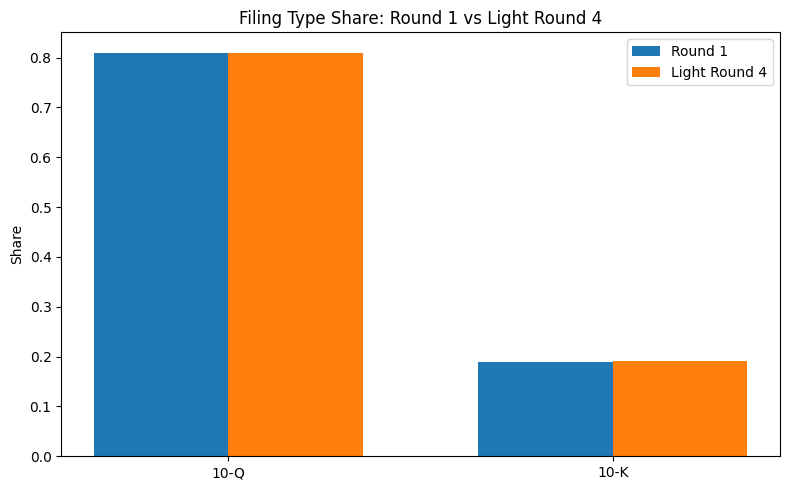

In [112]:
plot_df = filing_type_audit.reset_index().rename(columns={"index": "filing_type"})

plt.figure(figsize=(8, 5))
x = np.arange(len(plot_df))
width = 0.35

plt.bar(x - width/2, plot_df["round1_share"], width=width, label="Round 1")
plt.bar(x + width/2, plot_df["light_round4_share"], width=width, label="Light Round 4")

plt.xticks(x, plot_df["filing_type"])
plt.ylabel("Share")
plt.title("Filing Type Share: Round 1 vs Light Round 4")
plt.legend()
plt.tight_layout()
plt.show()

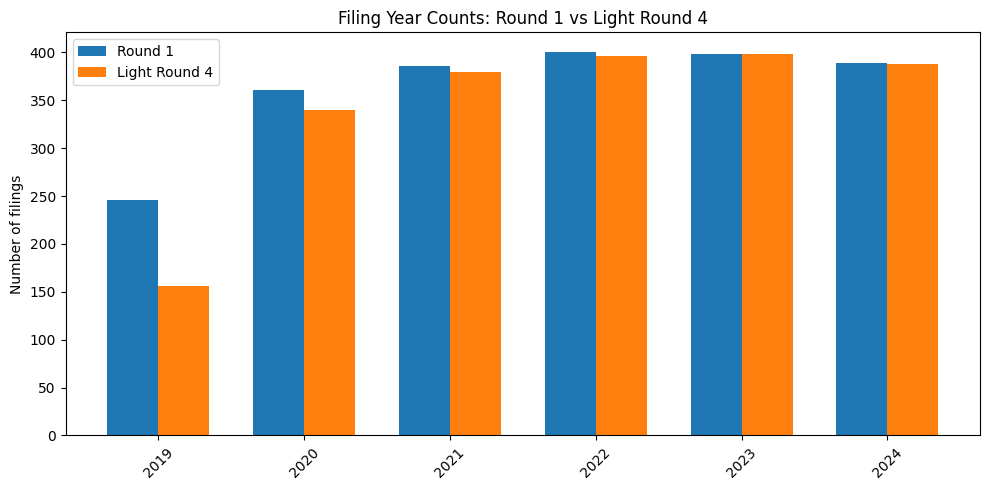

In [113]:
year_plot = year_audit.reset_index().rename(columns={"index": "filing_year"})

plt.figure(figsize=(10, 5))
x = np.arange(len(year_plot))
width = 0.35

plt.bar(x - width/2, year_plot["round1_count"], width=width, label="Round 1")
plt.bar(x + width/2, year_plot["light_round4_count"], width=width, label="Light Round 4")

plt.xticks(x, year_plot["filing_year"], rotation=45)
plt.ylabel("Number of filings")
plt.title("Filing Year Counts: Round 1 vs Light Round 4")
plt.legend()
plt.tight_layout()
plt.show()

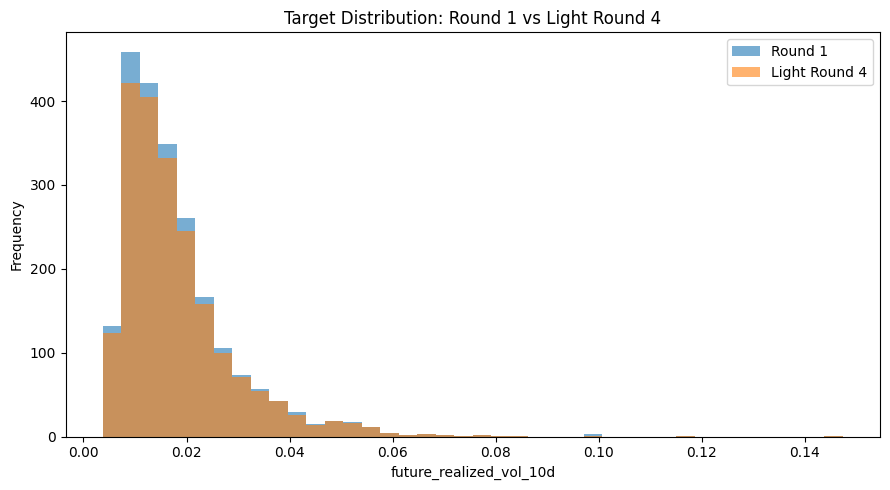

In [114]:
plt.figure(figsize=(9, 5))
plt.hist(round1[target_col].dropna(), bins=40, alpha=0.6, label="Round 1")
plt.hist(light_round4[target_col].dropna(), bins=40, alpha=0.6, label="Light Round 4")
plt.xlabel(target_col)
plt.ylabel("Frequency")
plt.title("Target Distribution: Round 1 vs Light Round 4")
plt.legend()
plt.tight_layout()
plt.show()

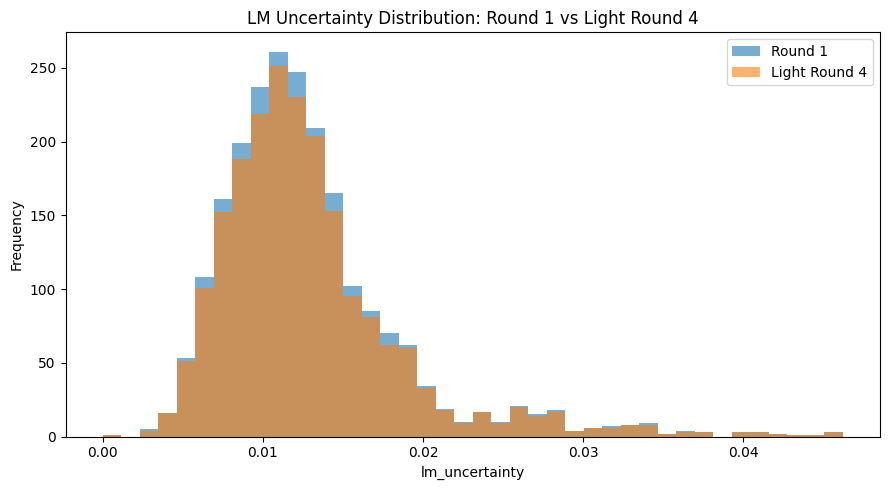

In [115]:
plt.figure(figsize=(9, 5))
plt.hist(round1["lm_uncertainty"].dropna(), bins=40, alpha=0.6, label="Round 1")
plt.hist(light_round4["lm_uncertainty"].dropna(), bins=40, alpha=0.6, label="Light Round 4")
plt.xlabel("lm_uncertainty")
plt.ylabel("Frequency")
plt.title("LM Uncertainty Distribution: Round 1 vs Light Round 4")
plt.legend()
plt.tight_layout()
plt.show()

In [116]:
retention_summary = pd.DataFrame({
    "metric": [
        "rows_round1",
        "rows_light_round4",
        "rows_lost",
        "retention_rate",
        "unique_tickers_round1",
        "unique_tickers_light_round4",
        "target_mean_round1",
        "target_mean_light_round4",
        "target_median_round1",
        "target_median_light_round4"
    ],
    "value": [
        len(round1),
        len(light_round4),
        len(lost_df),
        len(light_round4) / len(round1),
        round1["ticker"].nunique(),
        light_round4["ticker"].nunique(),
        round1[target_col].mean(),
        light_round4[target_col].mean(),
        round1[target_col].median(),
        light_round4[target_col].median()
    ]
})

retention_summary

,metric,value
0,rows_round1,2181.000000
1,rows_light_round4,2058.000000
2,rows_lost,123.000000
3,retention_rate,0.943604
4,unique_tickers_round1,123.000000
5,unique_tickers_light_round4,122.000000
6,target_mean_round1,0.018194
7,target_mean_light_round4,0.018219
8,target_median_round1,0.015091
9,target_median_light_round4,0.015183


In [117]:
filing_type_audit.to_csv(f"{OUT_DIR}/filing_type_audit.csv")
year_audit.to_csv(f"{OUT_DIR}/year_audit.csv")
firm_coverage.to_csv(f"{OUT_DIR}/firm_coverage.csv", index=False)
firm_loss_table.to_csv(f"{OUT_DIR}/firm_loss_table.csv", index=False)
target_audit.to_csv(f"{OUT_DIR}/target_audit.csv")
feature_distribution_audit.to_csv(f"{OUT_DIR}/feature_distribution_audit.csv", index=False)
period_audit.to_csv(f"{OUT_DIR}/period_audit.csv", index=False)
retention_by_type_year.to_csv(f"{OUT_DIR}/retention_by_type_year.csv", index=False)
retention_summary.to_csv(f"{OUT_DIR}/retention_summary.csv", index=False)

print("Saved all audit outputs.")

Saved all audit outputs.


In [ ]:
from google.colab import files

files.download(f"{OUT_DIR}/retention_summary.csv")
files.download(f"{OUT_DIR}/filing_type_audit.csv")
files.download(f"{OUT_DIR}/year_audit.csv")
files.download(f"{OUT_DIR}/firm_loss_table.csv")
files.download(f"{OUT_DIR}/feature_distribution_audit.csv")
files.download(f"{OUT_DIR}/retention_by_type_year.csv")